# Physics sensitivity

**What this shows:** how to generate and run a set of SWAN models that differ only in
their physics, from one base configuration, and compare the results. This is the
pattern behind sensitivity tests and calibration.

**Prerequisites:** [Tutorial 5: Choosing model settings](../tutorial/05_model_settings.ipynb)
and [Physics](physics.ipynb).

**You will learn:**

- how to derive variants of a configuration with `model_copy`
- how to generate and run one workspace per variant
- how to compare the variants

**Data used:** `etopo15s_perth.nc`, `era5-20230101.nc` and
`ww3-spectra-20230101-short.nc`. The runs use Docker and are skipped without it.

## Setup

In [1]:
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import xarray as xr
from rompy.backends import DockerConfig
from rompy.core.filters import Filter
from rompy.core.source import SourceFile, SourceWavespectra
from rompy.core.time import TimeRange
from rompy.logging import config as logging_config
from rompy.model import ModelRun

from rompy_swan.boundary import Boundnest1
from rompy_swan.components.cgrid import REGULAR
from rompy_swan.components.group import LOCKUP, OUTPUT, PHYSICS, STARTUP
from rompy_swan.components.lockup import COMPUTE_STAT
from rompy_swan.components.output import BLOCK
from rompy_swan.components.physics import FRICTION_JONSWAP, GEN3, SSWELL_ZIEGER, TRIAD
from rompy_swan.components.startup import COORDINATES, MODE, SET
from rompy_swan.config import SwanConfig
from rompy_swan.data import SwanDataGrid
from rompy_swan.grid import SwanGrid
from rompy_swan.interface import BoundaryInterface, DataInterface
from rompy_swan.subcomponents.physics import KOMEN, ST6C1, WESTHUYSEN
from rompy_swan.subcomponents.spectrum import SPECTRUM
from rompy_swan.subcomponents.startup import SPHERICAL

logging_config.update(level="WARNING")

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "physics_sensitivity"
shutil.rmtree(OUT_DIR, ignore_errors=True)

## 1. The base configuration

The stationary model at 15:00, with wind and boundary spectra, as in Tutorial 5.

In [2]:
grid = SwanGrid(x0=114.5, y0=-32.8, dx=0.02, dy=0.02, nx=71, ny=66)
period = TimeRange(start="2023-01-01T15:00", end="2023-01-01T16:00", interval="1h")
base = SwanConfig(
    startup=STARTUP(
        set=SET(direction_convention="nautical"),
        mode=MODE(kind="nonstationary"),
        coordinates=COORDINATES(kind=SPHERICAL()),
    ),
    cgrid=REGULAR(grid=grid.component, spectrum=SPECTRUM(mdc=36, flow=0.04, fhigh=1.0)),
    inpgrid=DataInterface(
        bottom=SwanDataGrid(
            var="bottom",
            source=SourceFile(uri=DATA_DIR / "etopo15s_perth.nc"),
            z1="z",
            fac=-1.0,
            coords={"x": "longitude", "y": "latitude"},
            buffer=0.1,
        ),
        input=[
            SwanDataGrid(
                var="wind",
                source=SourceFile(uri=DATA_DIR / "era5-20230101.nc"),
                z1="u10",
                z2="v10",
                coords={"x": "longitude", "y": "latitude"},
                filter=Filter(sort={"coords": ["latitude"]}),
                buffer=0.25,
            )
        ],
    ),
    boundary=BoundaryInterface(
        kind=Boundnest1(
            id="ww3",
            source=SourceWavespectra(
                uri=DATA_DIR / "ww3-spectra-20230101-short.nc", reader="read_ww3"
            ),
            sel_method="idw",
            sel_method_kwargs={"tolerance": 1.5},
            spacing=0.1,
        )
    ),
    physics=PHYSICS(gen=GEN3(), friction=FRICTION_JONSWAP(cfjon=0.038), triad=TRIAD()),
    output=OUTPUT(block=BLOCK(sname="COMPGRID", fname="swangrid.nc", output=["hsign", "tps"])),
    lockup=LOCKUP(compute=COMPUTE_STAT()),
)

## 2. Variants

`model_copy(update=...)` returns a copy with some fields replaced. Each variant
changes the source-term package of `GEN3`; ST6 also adds its swell dissipation.

In [3]:
variants = {
    "westhuysen": base.physics.model_copy(update={"gen": GEN3(source_terms=WESTHUYSEN())}),
    "komen": base.physics.model_copy(update={"gen": GEN3(source_terms=KOMEN())}),
    "st6": base.physics.model_copy(
        update={"gen": GEN3(source_terms=ST6C1()), "sswell": SSWELL_ZIEGER()}
    ),
}
for name, physics in variants.items():
    print(f"{name}: {physics.render().splitlines()[0]}")

westhuysen: GEN3 WESTHUYSEN DRAG WU
komen: GEN3 KOMEN DRAG WU
st6: GEN3 ST6 a1sds=4.7e-07 a2sds=6.6e-06 p1sds=4.0 p2sds=4.0 UP HWANG VECTAU U10PROXY windscaling=28.0 AGROW


`model_copy` does not check the new values; build the objects with their classes, as
here, so they are checked when created.

## 3. Generate and run

Each variant is a new `ModelRun` with its own run id, so each gets its own workspace.

In [4]:
def docker_available() -> bool:
    """Return True if the Docker daemon can be reached."""
    try:
        return subprocess.run(["docker", "info"], capture_output=True).returncode == 0
    except FileNotFoundError:
        return False


backend = DockerConfig(image="ghcr.io/rom-py/swan:41.51", executable="swan.exe")
results = {}
for name, physics in variants.items():
    config = base.model_copy(update={"physics": physics})
    modelrun = ModelRun(run_id=name, period=period, output_dir=OUT_DIR, config=config)
    workspace = Path(modelrun())
    if docker_available() and modelrun.run(backend, workspace_dir=workspace):
        results[name] = xr.open_dataset(workspace / "swangrid.nc").isel(time=0)
print(f"Runs completed: {list(results)}")

Runs completed: ['westhuysen', 'komen', 'st6']


## 4. Compare

The packages agree near the coast, where the waves come mostly from the boundary
swell, and differ offshore, where the wind sea grows under the sea breeze: the wind
input and whitecapping formulations differ most in how fast young wind sea grows.

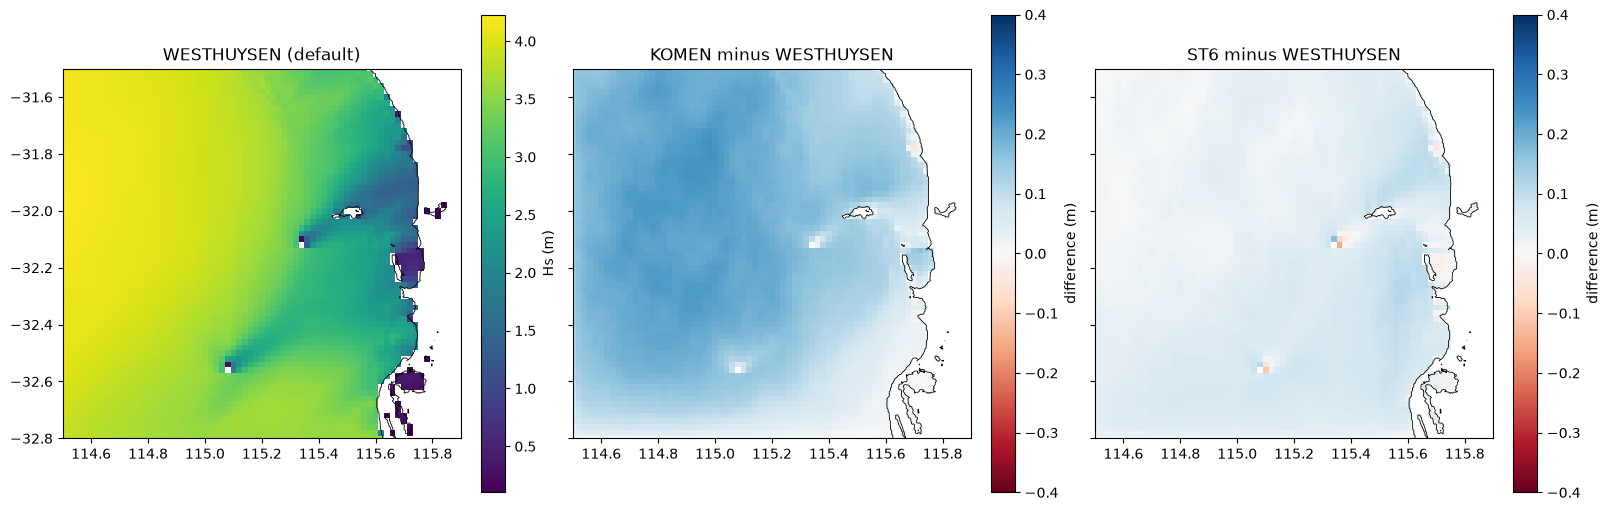

In [5]:
if len(results) == len(variants):
    etopo = xr.open_dataset(DATA_DIR / "etopo15s_perth.nc")
    reference = results["westhuysen"].hs
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, layout="constrained")
    reference.plot(ax=axes[0], cmap="viridis", cbar_kwargs={"label": "Hs (m)"})
    for ax, name in zip(axes[1:], ["komen", "st6"]):
        (results[name].hs - reference).plot(
            ax=ax, cmap="RdBu", vmin=-0.4, vmax=0.4, cbar_kwargs={"label": "difference (m)"}
        )
    titles = ["WESTHUYSEN (default)", "KOMEN minus WESTHUYSEN", "ST6 minus WESTHUYSEN"]
    for ax, title in zip(axes, titles):
        etopo.z.plot.contour(ax=ax, levels=[0], colors="k", linewidths=0.6)
        ax.set(xlim=(114.5, 115.9), ylim=(-32.8, -31.5), xlabel="", ylabel="", title=title)
        ax.set_aspect("equal")

In [6]:
if len(results) == len(variants):
    summary = {
        name: {
            "mean Hs (m)": float(result.hs.mean()),
            "max Hs (m)": float(result.hs.max()),
            "mean Tp (s)": float(result.tps.mean()),
        }
        for name, result in results.items()
    }
    for name, values in summary.items():
        print(f"{name:>10}: " + ", ".join(f"{k} {v:.2f}" for k, v in values.items()))

westhuysen: mean Hs (m) 3.43, max Hs (m) 4.23, mean Tp (s) 14.02
     komen: mean Hs (m) 3.58, max Hs (m) 4.38, mean Tp (s) 13.99
       st6: mean Hs (m) 3.47, max Hs (m) 4.23, mean Tp (s) 14.03


Which package is best depends on the site and should be decided by comparing with
measurements, for example buoys.

## Summary

- Derive variants of a base configuration with `model_copy(update=...)`.
- Give each variant its own `ModelRun` and run id, so the workspaces stay separate.
- Compare the results against a reference, and against observations when choosing.